In [10]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", google_api_key=api_key, temperature=0.7)

Google api key is set


In [11]:
from typing import TypedDict, Literal, Optional, List, Annotated
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages

class ImageProcessingRequest(BaseModel):
    operation: Literal[
        "resize",
        "convert",
        "compress",
        "rotate",
        "metadata"
    ] = Field(description="Image processing operation to perform")

    image_path: str = Field(
        description="Path of the image file"
    )

    height: Optional[int] = Field(
        default=None,
        description="New image height for resize operation"
    )

    width: Optional[int] = Field(
        default=None,
        description="New image width for resize operation"
    )
    format: Optional[str] = Field(
        default=None,
        description="Target image format like JPG, PNG, WEBP"
    )

    quality: Optional[int] = Field(
        default=None,
        description="Compression quality from 1-100"
    )

    rotation_angle: Optional[int] = Field(
        default=None,
        description="Rotation angle like 90, 180, 270 degrees"
    )

class graph_schema(TypedDict):
    messages: Annotated[list, add_messages]
    request: ImageProcessingRequest
    result: str

llm_with_schema = llm.with_structured_output(ImageProcessingRequest)




In [12]:
from langchain_core.tools import tool

def resize_image(state: graph_schema) -> graph_schema:
    """
    Tool to resize image
    Args:
        height: Target height of the image
        width: Target width of the image
        image_path: Location of the target image
    """

def convert_image(state: graph_schema) -> graph_schema:
    """
    Tool to convert image type(jpg, jpeg, png, wpeg)
    Args:
        format: Target conversion type of image
        image_path: Location of the target image
    """

def compress_image(state: graph_schema) -> graph_schema:
    """
    Tool to compress image
    Args:
        quality: after compression quality of image
        image_path: Location of the target image
    """

def rotate_image(state: graph_schema) -> graph_schema:
    """
    Tool to rotate image
    Args:
        rotation_angle: Angle at which image is to be rotated
        image_path: Location of the target image
    """

def metadata_extraction_image(state: graph_schema) -> graph_schema:
    """
    Tool to extract metadata of image
    Args:
        height: Target height of the image
        width: Target width of the image
        image_path: Location of the target image
    """

In [13]:
from langchain_core.messages import ToolMessage

def llm_node(state: graph_schema) -> graph_schema:
    message = state['messages']
    response = llm_with_schema.invoke(message)
    
    state['request'] = response
    return state



def condition(state: graph_schema) -> str:
    request = state['request']
    return request.operation

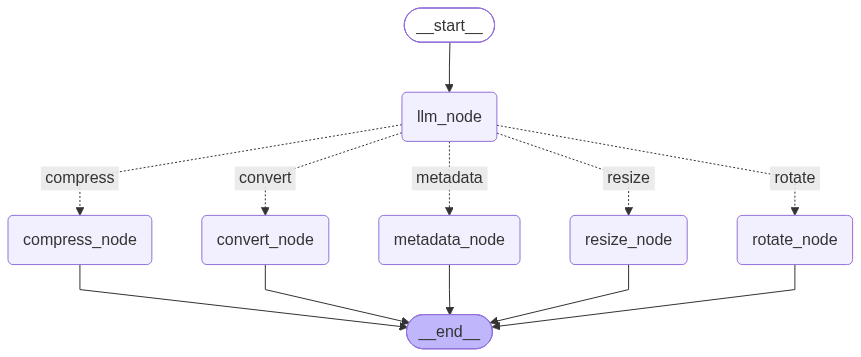

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("resize_node", resize_image)
graph.add_node("convert_node", convert_image)
graph.add_node("compress_node", compress_image)
graph.add_node("rotate_node", rotate_image)
graph.add_node("metadata_node", metadata_extraction_image)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", condition, {
        "resize": "resize_node",
        "convert": "convert_node",
        "compress": "compress_node",
        "rotate": "rotate_node",
        "metadata": "metadata_node",
    })
graph.add_edge("resize_node", END)
graph.add_edge("convert_node", END)
graph.add_edge("compress_node", END)
graph.add_edge("rotate_node", END)
graph.add_edge("metadata_node", END)

result = graph.compile()
result